# Robustness and simulation validation

This notebook validates the persistent-parameter promotion-planning model
developed in notebook 05c.

The analysis has two parts.

**Empirical decision-layer robustness**

- Wasserstein-radius sensitivity;
- scenario-reduction sensitivity with radius recalibration;
- horizon, cooldown, and promotion-cap sensitivity;
- sensitivity to the partially identified displacement and persistence
  parameters.

**Controlled simulation validation**

- generate noisy behavioral calibrations around known persistent DGPs;
- construct myopic, nominal, and Wasserstein-DRO schedules;
- evaluate all schedules under the true persistent behavioral type;
- estimate the value of dynamic optimization, value of robustness,
  oracle gap, and regret reduction.

The behavioral vector remains fixed throughout each planning horizon:

\[
\theta_t=\theta
\qquad
\forall t.
\]

The rectangular recursion is not used in this notebook.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import hashlib
import json
import pickle
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import (
    linear_sum_assignment,
    minimize_scalar,
)
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

CURRENT_DIR = Path.cwd().resolve()
POSSIBLE_ROOTS = [
    CURRENT_DIR,
    CURRENT_DIR.parent,
]

PROJECT_ROOT = next(
    (
        root
        for root in POSSIBLE_ROOTS
        if (
            root
            / "data"
            / "processed"
        ).is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate project root from {CURRENT_DIR}"
    )

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)
TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)
FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)
MODEL_DIR = (
    PROJECT_ROOT
    / "results"
    / "models"
)
CACHE_DIR = (
    PROCESSED_DIR
    / "robustness_cache"
)

for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    MODEL_DIR,
    CACHE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

PARAMETER_PATH = (
    PROCESSED_DIR
    / "stockpiling_behavioral_draws.pkl"
)
BASELINE_ARTIFACT_PATH = (
    PROCESSED_DIR
    / "persistent_parameter_dro_artifact.pkl"
)

RANDOM_SEED = 42
VALUE_TOLERANCE = 1e-9

PARAMETER_COLUMNS = [
    "price_elasticity",
    "promotion_lift_log",
    "displacement_strength",
    "inventory_persistence",
]

DISCOUNT_ACTIONS = np.array(
    [0.00, 0.10, 0.20, 0.30],
    dtype=float,
)

BASELINE_HORIZON = 12
BASELINE_DISCOUNT_FACTOR = 0.995
BASELINE_COOLDOWN = 2
BASELINE_MAX_PROMOTIONS = 4

FINE_ALPHA_GRID = np.round(
    np.arange(
        2.10,
        2.50 + 0.0025,
        0.005,
    ),
    10,
)

BROAD_ALPHA_GRID = np.round(
    np.arange(
        2.00,
        2.60 + 0.005,
        0.01,
    ),
    10,
)

KEY_ALPHA_VALUES = np.array(
    [
        2.19,
        2.24,
        2.25,
        2.34,
        2.50,
    ],
    dtype=float,
)

RADIUS_MULTIPLIERS = np.array(
    [
        0.0,
        0.25,
        0.50,
        0.75,
        1.00,
        1.25,
        1.50,
        2.00,
    ],
    dtype=float,
)

SCENARIO_COUNTS = [
    20,
    40,
    80,
]

RUN_FULL_SUPPORT = False

STRUCTURAL_CONFIGURATIONS = [
    {
        "name": "short_horizon",
        "horizon": 8,
        "cooldown": 2,
        "max_promotions": 3,
        "discount_factor": 0.995,
    },
    {
        "name": "short_cooldown",
        "horizon": 12,
        "cooldown": 1,
        "max_promotions": 4,
        "discount_factor": 0.995,
    },
    {
        "name": "baseline",
        "horizon": 12,
        "cooldown": 2,
        "max_promotions": 4,
        "discount_factor": 0.995,
    },
    {
        "name": "long_cooldown",
        "horizon": 12,
        "cooldown": 3,
        "max_promotions": 3,
        "discount_factor": 0.995,
    },
    {
        "name": "long_horizon",
        "horizon": 16,
        "cooldown": 3,
        "max_promotions": 4,
        "discount_factor": 0.995,
    },
]

BEHAVIORAL_VARIANTS = [
    "baseline",
    "no_displacement",
    "half_displacement",
    "double_displacement",
    "low_persistence",
    "medium_persistence",
    "high_persistence",
    "zero_nonprice_lift",
]

RADIUS_RESAMPLE_REPLICATIONS = 60
RADIUS_RESAMPLE_SIZE = 80
RADIUS_QUANTILE = 0.90

SIMULATION_REPLICATIONS = 20
SIMULATION_ESTIMATION_DRAWS = 40
SIMULATION_SCENARIO_COUNT = 20
SIMULATION_RADIUS_REPLICATIONS = 25
SIMULATION_OFFSETS = np.array(
    [
        -0.01,
        0.05,
    ],
    dtype=float,
)

EXTENDED_SIMULATIONS = False

if EXTENDED_SIMULATIONS:
    SIMULATION_REPLICATIONS = 100
    SIMULATION_ESTIMATION_DRAWS = 100
    SIMULATION_RADIUS_REPLICATIONS = 50

RADIUS_SENSITIVITY_PATH = (
    TABLE_DIR
    / "robustness_radius_sensitivity.csv"
)
SCENARIO_SENSITIVITY_PATH = (
    TABLE_DIR
    / "robustness_scenario_reduction.csv"
)
STRUCTURAL_SENSITIVITY_PATH = (
    TABLE_DIR
    / "robustness_structural_design.csv"
)
BEHAVIORAL_SENSITIVITY_PATH = (
    TABLE_DIR
    / "robustness_behavioral_calibration.csv"
)
SIMULATION_RAW_PATH = (
    TABLE_DIR
    / "simulation_validation_raw.csv"
)
SIMULATION_SUMMARY_PATH = (
    TABLE_DIR
    / "simulation_validation_summary.csv"
)
ROBUSTNESS_SUMMARY_PATH = (
    TABLE_DIR
    / "robustness_consolidated_summary.csv"
)

RADIUS_FIGURE_PATH = (
    FIGURE_DIR
    / "robustness_radius_thresholds.png"
)
SCENARIO_FIGURE_PATH = (
    FIGURE_DIR
    / "robustness_scenario_thresholds.png"
)
STRUCTURAL_FIGURE_PATH = (
    FIGURE_DIR
    / "robustness_structural_thresholds.png"
)
BEHAVIORAL_FIGURE_PATH = (
    FIGURE_DIR
    / "robustness_behavioral_thresholds.png"
)
SIMULATION_FIGURE_PATH = (
    FIGURE_DIR
    / "simulation_value_of_robustness.png"
)
SIMULATION_REGRET_FIGURE_PATH = (
    FIGURE_DIR
    / "simulation_regret_reduction.png"
)

CONFIGURATION_PATH = (
    MODEL_DIR
    / "robustness_and_simulation_configuration.json"
)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print(
    "Simulation replications:",
    SIMULATION_REPLICATIONS,
)

Project root: C:\Users\janza\price-of-extrapolation
Python: 3.13.3
Simulation replications: 20


## 2. Load the persistent-parameter artifact and behavioral draws

In [2]:
if not PARAMETER_PATH.is_file():
    raise FileNotFoundError(
        "Run 04_stockpiling_calibration_revised_v2.ipynb first."
    )

if not BASELINE_ARTIFACT_PATH.is_file():
    raise FileNotFoundError(
        "Run 05c_persistent_parameter_dro.ipynb first."
    )

parameter_draws = pd.read_pickle(
    PARAMETER_PATH
).copy()

baseline_artifact = pd.read_pickle(
    BASELINE_ARTIFACT_PATH
)

required_draw_columns = set(
    PARAMETER_COLUMNS
).union(
    {
        "base_demand",
        "regular_price",
        "unit_cost",
        "draw_weight",
    }
)

missing = required_draw_columns.difference(
    parameter_draws.columns
)

if missing:
    raise ValueError(
        "Behavioral-draw artifact is missing columns: "
        f"{sorted(missing)}"
    )

for column in required_draw_columns:
    parameter_draws[column] = pd.to_numeric(
        parameter_draws[column],
        errors="coerce",
    )

valid = np.ones(
    len(parameter_draws),
    dtype=bool,
)

for column in required_draw_columns:
    valid &= (
        parameter_draws[column].notna()
        & np.isfinite(
            parameter_draws[column]
        )
    )

valid &= parameter_draws[
    "draw_weight"
].gt(0)

parameter_draws = (
    parameter_draws.loc[valid]
    .reset_index(drop=True)
)

parameter_draws["draw_weight"] = (
    parameter_draws["draw_weight"]
    / parameter_draws["draw_weight"].sum()
)

DRAW_WEIGHTS = parameter_draws[
    "draw_weight"
].to_numpy(dtype=float)

THETA = parameter_draws[
    PARAMETER_COLUMNS
].to_numpy(dtype=float)

BASE_DEMAND = float(
    np.average(
        parameter_draws["base_demand"],
        weights=DRAW_WEIGHTS,
    )
)
REGULAR_PRICE = float(
    np.average(
        parameter_draws["regular_price"],
        weights=DRAW_WEIGHTS,
    )
)
UNIT_COST = float(
    np.average(
        parameter_draws["unit_cost"],
        weights=DRAW_WEIGHTS,
    )
)

BASELINE_SCHEDULES = np.asarray(
    baseline_artifact[
        "schedules"
    ],
    dtype=float,
)

BASELINE_PROMOTION_COUNT = np.asarray(
    baseline_artifact[
        "schedule_promotion_count"
    ],
    dtype=int,
)

BASELINE_TOTAL_DEPTH = np.asarray(
    baseline_artifact[
        "schedule_total_depth"
    ],
    dtype=float,
)

BASELINE_BASE_MATRIX = np.asarray(
    baseline_artifact[
        "base_value_matrix"
    ],
    dtype=float,
)

BASELINE_EXPOSURE_MATRIX = np.asarray(
    baseline_artifact[
        "exposure_matrix"
    ],
    dtype=float,
)

BASELINE_SCENARIO_INDICES = np.asarray(
    baseline_artifact[
        "scenario_indices"
    ],
    dtype=int,
)

BASELINE_SCENARIO_WEIGHTS = np.asarray(
    baseline_artifact[
        "scenario_weights"
    ],
    dtype=float,
)

BASELINE_TRANSPORT_COST = np.asarray(
    baseline_artifact[
        "transport_cost"
    ],
    dtype=float,
)

BASELINE_RHO = float(
    baseline_artifact[
        "calibrated_rho"
    ]
)

print(
    "Behavioral draws:",
    len(parameter_draws),
)
print(
    "Baseline schedules:",
    len(BASELINE_SCHEDULES),
)
print(
    "Baseline scenarios:",
    len(BASELINE_SCENARIO_INDICES),
)
print(
    "Baseline rho:",
    f"{BASELINE_RHO:.4f}",
)

Behavioral draws: 564
Baseline schedules: 3169
Baseline scenarios: 40
Baseline rho: 0.9086


## 3. Core reusable functions

In [3]:
@dataclass(frozen=True)
class PlanningDesign:
    horizon: int
    cooldown: int
    max_promotions: int
    discount_factor: float


def enumerate_feasible_schedules(
    design: PlanningDesign,
    actions: np.ndarray = DISCOUNT_ACTIONS,
) -> np.ndarray:
    schedules: list[
        tuple[float, ...]
    ] = []

    def recurse(
        time_index: int,
        cooldown_remaining: int,
        promotion_count: int,
        path: list[float],
    ) -> None:
        if time_index == design.horizon:
            schedules.append(
                tuple(path)
            )
            return

        if cooldown_remaining > 0:
            feasible_actions = [
                0.0
            ]
        else:
            feasible_actions = [
                float(action)
                for action in actions
                if (
                    action <= 1e-12
                    or promotion_count
                    < design.max_promotions
                )
            ]

        for discount_depth in feasible_actions:
            promoted = (
                discount_depth > 1e-12
            )

            next_cooldown = (
                design.cooldown
                if promoted
                else max(
                    cooldown_remaining - 1,
                    0,
                )
            )

            next_promotion_count = (
                promotion_count
                + int(
                    promoted
                )
            )

            path.append(
                discount_depth
            )

            recurse(
                time_index + 1,
                next_cooldown,
                next_promotion_count,
                path,
            )

            path.pop()

    recurse(
        time_index=0,
        cooldown_remaining=0,
        promotion_count=0,
        path=[],
    )

    return np.asarray(
        schedules,
        dtype=float,
    )


def schedule_metadata(
    schedules: np.ndarray,
) -> dict[str, np.ndarray | int]:
    promotion_count = (
        schedules > 1e-12
    ).sum(axis=1)

    total_depth = schedules.sum(
        axis=1
    )

    first_week = np.full(
        len(schedules),
        np.nan,
        dtype=float,
    )

    for schedule_index, schedule in enumerate(
        schedules
    ):
        promoted = np.flatnonzero(
            schedule > 1e-12
        )

        if len(promoted) > 0:
            first_week[
                schedule_index
            ] = float(
                promoted[0] + 1
            )

    no_promotion_index = int(
        np.flatnonzero(
            promotion_count == 0
        )[0]
    )

    return {
        "promotion_count": (
            promotion_count.astype(int)
        ),
        "total_depth": (
            total_depth.astype(float)
        ),
        "first_week": (
            first_week
        ),
        "no_promotion_index": (
            no_promotion_index
        ),
    }


def compute_value_matrices(
    schedules: np.ndarray,
    theta: np.ndarray,
    discount_factor: float,
) -> tuple[
    np.ndarray,
    np.ndarray,
]:
    schedules = np.asarray(
        schedules,
        dtype=float,
    )
    theta = np.asarray(
        theta,
        dtype=float,
    )

    schedule_count = len(
        schedules
    )
    draw_count = len(
        theta
    )

    base_matrix = np.empty(
        (
            schedule_count,
            draw_count,
        ),
        dtype=np.float32,
    )

    exposure_matrix = np.empty_like(
        base_matrix
    )

    for draw_index, draw in enumerate(
        theta
    ):
        (
            price_elasticity,
            promotion_lift_log,
            displacement_strength,
            inventory_persistence,
        ) = draw

        inventory = np.zeros(
            schedule_count,
            dtype=float,
        )
        base_value = np.zeros(
            schedule_count,
            dtype=float,
        )
        exposure = np.zeros(
            schedule_count,
            dtype=float,
        )

        for time_index in range(
            schedules.shape[1]
        ):
            depth = schedules[
                :,
                time_index,
            ]

            demand = (
                BASE_DEMAND
                * np.power(
                    np.maximum(
                        1.0 - depth,
                        1e-8,
                    ),
                    -price_elasticity,
                )
                * np.exp(
                    promotion_lift_log
                    * (
                        depth > 1e-12
                    )
                    - displacement_strength
                    * np.maximum(
                        inventory,
                        0.0,
                    )
                )
            )

            price = (
                REGULAR_PRICE
                * (
                    1.0 - depth
                )
            )

            discount_weight = (
                discount_factor
                ** time_index
            )

            base_value += (
                discount_weight
                * (
                    price
                    - UNIT_COST
                )
                * demand
            )

            exposure += (
                discount_weight
                * depth
                * demand
            )

            inventory = (
                inventory_persistence
                * np.maximum(
                    inventory,
                    0.0,
                )
                + depth
            )

        base_matrix[
            :,
            draw_index,
        ] = base_value.astype(
            np.float32
        )

        exposure_matrix[
            :,
            draw_index,
        ] = exposure.astype(
            np.float32
        )

    return (
        base_matrix,
        exposure_matrix,
    )


def design_cache_key(
    name: str,
    design: PlanningDesign,
    theta_label: str,
) -> str:
    payload = (
        f"{name}|{design.horizon}|"
        f"{design.cooldown}|"
        f"{design.max_promotions}|"
        f"{design.discount_factor}|"
        f"{theta_label}"
    )

    digest = hashlib.sha256(
        payload.encode(
            "utf-8"
        )
    ).hexdigest()[:12]

    return (
        f"{name}_{digest}.pkl"
    )


def load_or_compute_design_values(
    name: str,
    design: PlanningDesign,
    theta: np.ndarray,
    theta_label: str,
    force_recompute: bool = False,
) -> dict[str, object]:
    cache_path = (
        CACHE_DIR
        / design_cache_key(
            name,
            design,
            theta_label,
        )
    )

    if (
        cache_path.is_file()
        and not force_recompute
    ):
        return pd.read_pickle(
            cache_path
        )

    schedules = (
        enumerate_feasible_schedules(
            design
        )
    )

    metadata = schedule_metadata(
        schedules
    )

    (
        base_matrix,
        exposure_matrix,
    ) = compute_value_matrices(
        schedules=schedules,
        theta=theta,
        discount_factor=(
            design.discount_factor
        ),
    )

    artifact = {
        "name": name,
        "design": design,
        "schedules": schedules,
        "metadata": metadata,
        "base_matrix": base_matrix,
        "exposure_matrix": (
            exposure_matrix
        ),
    }

    pd.to_pickle(
        artifact,
        cache_path,
    )

    return artifact

In [4]:
def weighted_standardization(
    theta: np.ndarray,
    weights: np.ndarray,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    mean = np.average(
        theta,
        axis=0,
        weights=weights,
    )

    variance = np.average(
        (
            theta - mean
        ) ** 2,
        axis=0,
        weights=weights,
    )

    scale = np.sqrt(
        variance
    )

    scale = np.where(
        scale > 1e-10,
        scale,
        1.0,
    )

    standardized = (
        theta - mean
    ) / scale

    return (
        standardized,
        mean,
        scale,
    )


def reduce_weighted_distribution(
    theta: np.ndarray,
    weights: np.ndarray,
    scenario_count: int,
    random_seed: int,
    standardization_mean: (
        np.ndarray | None
    ) = None,
    standardization_scale: (
        np.ndarray | None
    ) = None,
) -> dict[str, np.ndarray]:
    theta = np.asarray(
        theta,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    weights = (
        weights
        / weights.sum()
    )

    if (
        standardization_mean is None
        or standardization_scale is None
    ):
        (
            standardized,
            mean,
            scale,
        ) = weighted_standardization(
            theta,
            weights,
        )
    else:
        mean = np.asarray(
            standardization_mean,
            dtype=float,
        )
        scale = np.asarray(
            standardization_scale,
            dtype=float,
        )
        standardized = (
            theta - mean
        ) / scale

    distinct_count = len(
        np.unique(
            np.round(
                standardized,
                10,
            ),
            axis=0,
        )
    )

    scenario_count = min(
        int(
            scenario_count
        ),
        len(theta),
        distinct_count,
    )

    if scenario_count <= 1:
        indices = np.array(
            [
                int(
                    np.argmax(
                        weights
                    )
                )
            ],
            dtype=int,
        )
        reduced_weights = np.array(
            [1.0],
            dtype=float,
        )
    elif scenario_count == len(
        theta
    ):
        indices = np.arange(
            len(theta),
            dtype=int,
        )
        reduced_weights = (
            weights.copy()
        )
    else:
        kmeans = KMeans(
            n_clusters=scenario_count,
            random_state=random_seed,
            n_init=20,
        )

        kmeans.fit(
            standardized,
            sample_weight=weights,
        )

        indices_list = []
        reduced_weights_list = []

        for cluster_id in range(
            scenario_count
        ):
            members = np.flatnonzero(
                kmeans.labels_
                == cluster_id
            )

            center = (
                kmeans.cluster_centers_[
                    cluster_id
                ]
            )

            distance = np.linalg.norm(
                standardized[
                    members
                ]
                - center,
                axis=1,
            )

            indices_list.append(
                int(
                    members[
                        np.argmin(
                            distance
                        )
                    ]
                )
            )

            reduced_weights_list.append(
                float(
                    weights[
                        members
                    ].sum()
                )
            )

        indices = np.asarray(
            indices_list,
            dtype=int,
        )

        reduced_weights = np.asarray(
            reduced_weights_list,
            dtype=float,
        )

    reduced_weights = (
        reduced_weights
        / reduced_weights.sum()
    )

    reduced_standardized = (
        theta[
            indices
        ]
        - mean
    ) / scale

    cost_matrix = cdist(
        reduced_standardized,
        reduced_standardized,
        metric="euclidean",
    )

    return {
        "indices": indices,
        "weights": reduced_weights,
        "cost_matrix": cost_matrix,
        "standardized": (
            reduced_standardized
        ),
        "mean": mean,
        "scale": scale,
    }


def equal_weight_wasserstein(
    sample_a: np.ndarray,
    sample_b: np.ndarray,
) -> float:
    if len(sample_a) != len(sample_b):
        raise ValueError(
            "Samples must have equal size."
        )

    cost = cdist(
        sample_a,
        sample_b,
        metric="euclidean",
    )

    rows, columns = (
        linear_sum_assignment(
            cost
        )
    )

    return float(
        cost[
            rows,
            columns,
        ].mean()
    )


def calibrate_instability_radius(
    standardized_theta: np.ndarray,
    weights: np.ndarray,
    replications: int,
    resample_size: int,
    quantile: float,
    random_seed: int,
) -> float:
    standardized_theta = np.asarray(
        standardized_theta,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    weights = (
        weights
        / weights.sum()
    )

    if len(standardized_theta) <= 1:
        return 0.0

    resample_size = min(
        int(
            resample_size
        ),
        max(
            10,
            len(
                standardized_theta
            ),
        ),
    )

    rng = np.random.default_rng(
        random_seed
    )

    distances = []

    for _ in range(
        replications
    ):
        first = rng.choice(
            len(
                standardized_theta
            ),
            size=resample_size,
            replace=True,
            p=weights,
        )

        second = rng.choice(
            len(
                standardized_theta
            ),
            size=resample_size,
            replace=True,
            p=weights,
        )

        distances.append(
            equal_weight_wasserstein(
                standardized_theta[
                    first
                ],
                standardized_theta[
                    second
                ],
            )
        )

    return float(
        np.quantile(
            distances,
            quantile,
        )
    )

In [5]:
def wasserstein_worst_case_expectation(
    scenario_values: np.ndarray,
    nominal_weights: np.ndarray,
    cost_matrix: np.ndarray,
    rho: float,
) -> float:
    values = np.asarray(
        scenario_values,
        dtype=float,
    )

    weights = np.asarray(
        nominal_weights,
        dtype=float,
    )

    nominal_value = float(
        np.dot(
            weights,
            values,
        )
    )

    if rho <= 1e-12:
        return nominal_value

    value_range = float(
        values.max()
        - values.min()
    )

    positive_cost = (
        cost_matrix[
            cost_matrix > 1e-12
        ]
    )

    if (
        value_range <= 1e-12
        or len(
            positive_cost
        ) == 0
    ):
        return float(
            values.min()
        )

    lambda_upper = (
        value_range
        / float(
            positive_cost.min()
        )
        + 1.0
    )

    def dual_value(
        multiplier: float,
    ) -> float:
        transported = (
            values[None, :]
            + float(multiplier)
            * cost_matrix
        )

        source_minima = (
            transported.min(
                axis=1
            )
        )

        return float(
            -float(multiplier)
            * rho
            + np.dot(
                weights,
                source_minima,
            )
        )

    result = minimize_scalar(
        lambda multiplier: -dual_value(
            float(multiplier)
        ),
        bounds=(
            0.0,
            lambda_upper,
        ),
        method="bounded",
        options={
            "xatol": 1e-9,
        },
    )

    robust_value = max(
        dual_value(0.0),
        dual_value(
            float(
                result.x
            )
        ),
        dual_value(
            lambda_upper
        ),
    )

    return float(
        np.clip(
            robust_value,
            float(
                values.min()
            ),
            nominal_value,
        )
    )


def tie_break_key(
    schedule_index: int,
    promotion_count: np.ndarray,
    total_depth: np.ndarray,
) -> tuple[
    int,
    float,
    int,
]:
    return (
        int(
            promotion_count[
                schedule_index
            ]
        ),
        float(
            total_depth[
                schedule_index
            ]
        ),
        int(
            schedule_index
        ),
    )


def best_schedule_from_values(
    values: np.ndarray,
    promotion_count: np.ndarray,
    total_depth: np.ndarray,
) -> int:
    maximum = float(
        values.max()
    )

    candidates = np.flatnonzero(
        values
        >= maximum
        - VALUE_TOLERANCE
    )

    return int(
        min(
            candidates,
            key=lambda index: (
                tie_break_key(
                    int(index),
                    promotion_count,
                    total_depth,
                )
            ),
        )
    )


def solve_robust_schedule(
    base_matrix: np.ndarray,
    exposure_matrix: np.ndarray,
    scenario_indices: np.ndarray,
    scenario_weights: np.ndarray,
    cost_matrix: np.ndarray,
    rho: float,
    alpha: float,
    promotion_count: np.ndarray,
    total_depth: np.ndarray,
    warm_start: int | None = None,
) -> dict[str, float | int]:
    scenario_values = (
        base_matrix[
            :,
            scenario_indices,
        ].astype(float)
        + float(alpha)
        * exposure_matrix[
            :,
            scenario_indices,
        ].astype(float)
    )

    nominal_values = (
        scenario_values
        @ scenario_weights
    )

    order = np.argsort(
        -nominal_values,
        kind="stable",
    )

    best_index = -1
    best_robust_value = -np.inf
    evaluated: set[int] = set()

    if warm_start is not None:
        warm_start = int(
            warm_start
        )

        best_robust_value = (
            wasserstein_worst_case_expectation(
                scenario_values[
                    warm_start
                ],
                scenario_weights,
                cost_matrix,
                rho,
            )
        )

        best_index = warm_start
        evaluated.add(
            warm_start
        )

    for raw_index in order:
        schedule_index = int(
            raw_index
        )

        nominal_upper_bound = float(
            nominal_values[
                schedule_index
            ]
        )

        if (
            best_index >= 0
            and nominal_upper_bound
            < best_robust_value
            - VALUE_TOLERANCE
        ):
            break

        if schedule_index in evaluated:
            continue

        robust_value = (
            wasserstein_worst_case_expectation(
                scenario_values[
                    schedule_index
                ],
                scenario_weights,
                cost_matrix,
                rho,
            )
        )

        evaluated.add(
            schedule_index
        )

        improve = (
            robust_value
            > best_robust_value
            + VALUE_TOLERANCE
        )

        tie_better = (
            abs(
                robust_value
                - best_robust_value
            )
            <= VALUE_TOLERANCE
            and (
                best_index < 0
                or tie_break_key(
                    schedule_index,
                    promotion_count,
                    total_depth,
                )
                < tie_break_key(
                    best_index,
                    promotion_count,
                    total_depth,
                )
            )
        )

        if improve or tie_better:
            best_index = (
                schedule_index
            )
            best_robust_value = float(
                robust_value
            )

    if best_index < 0:
        raise RuntimeError(
            "No robust schedule was evaluated."
        )

    return {
        "schedule_index": int(
            best_index
        ),
        "robust_value": float(
            best_robust_value
        ),
        "evaluated_count": int(
            len(evaluated)
        ),
    }


def threshold_on_grid(
    selected_indices: list[int],
    alpha_grid: np.ndarray,
    promotion_count: np.ndarray,
) -> float:
    for alpha, schedule_index in zip(
        alpha_grid,
        selected_indices,
    ):
        if (
            promotion_count[
                schedule_index
            ]
            > 0
        ):
            return float(
                alpha
            )

    return np.nan


def exact_nominal_threshold(
    base_matrix: np.ndarray,
    exposure_matrix: np.ndarray,
    weights: np.ndarray,
    no_promotion_index: int,
) -> float:
    nominal_base = (
        base_matrix.astype(float)
        @ weights
    )

    nominal_exposure = (
        exposure_matrix.astype(float)
        @ weights
    )

    eligible = (
        nominal_exposure
        > 1e-12
    )

    crossing = (
        nominal_base[
            no_promotion_index
        ]
        - nominal_base[
            eligible
        ]
    ) / nominal_exposure[
        eligible
    ]

    return float(
        np.maximum(
            crossing,
            0.0,
        ).min()
    )


def oracle_values_indices(
    base_matrix: np.ndarray,
    exposure_matrix: np.ndarray,
    alpha: float,
    chunk_size: int = 256,
) -> tuple[
    np.ndarray,
    np.ndarray,
]:
    draw_count = (
        base_matrix.shape[
            1
        ]
    )

    best_values = np.full(
        draw_count,
        -np.inf,
        dtype=float,
    )

    best_indices = np.zeros(
        draw_count,
        dtype=int,
    )

    for start in range(
        0,
        len(
            base_matrix
        ),
        chunk_size,
    ):
        stop = min(
            start + chunk_size,
            len(
                base_matrix
            ),
        )

        values = (
            base_matrix[
                start:stop
            ].astype(float)
            + float(alpha)
            * exposure_matrix[
                start:stop
            ].astype(float)
        )

        local_indices = np.argmax(
            values,
            axis=0,
        )

        local_values = values[
            local_indices,
            np.arange(
                draw_count
            ),
        ]

        improve = (
            local_values
            > best_values
            + VALUE_TOLERANCE
        )

        best_values[
            improve
        ] = local_values[
            improve
        ]

        best_indices[
            improve
        ] = (
            start
            + local_indices[
                improve
            ]
        )

    return (
        best_values,
        best_indices,
    )

## 4. Baseline distribution standardization

In [6]:
(
    THETA_STANDARDIZED,
    THETA_MEAN,
    THETA_SCALE,
) = weighted_standardization(
    THETA,
    DRAW_WEIGHTS,
)

baseline_distribution = (
    reduce_weighted_distribution(
        theta=THETA,
        weights=DRAW_WEIGHTS,
        scenario_count=len(
            BASELINE_SCENARIO_INDICES
        ),
        random_seed=RANDOM_SEED,
        standardization_mean=(
            THETA_MEAN
        ),
        standardization_scale=(
            THETA_SCALE
        ),
    )
)

print(
    "Weighted parameter center:",
    dict(
        zip(
            PARAMETER_COLUMNS,
            THETA_MEAN,
        )
    ),
)

Weighted parameter center: {'price_elasticity': np.float64(1.5911592064775038), 'promotion_lift_log': np.float64(-0.027458163026882147), 'displacement_strength': np.float64(0.14935572223581592), 'inventory_persistence': np.float64(0.35651542620042265)}


## 5. Wasserstein-radius sensitivity

In [8]:
import numpy as np


def weighted_quantile(values, weights, quantile):
    """
    Calculate a weighted quantile.

    Parameters
    ----------
    values : array-like
        Observed values.
    weights : array-like
        Non-negative weights corresponding to each value.
    quantile : float
        Desired quantile between 0 and 1, e.g. 0.10 for the 10th percentile.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if values.shape != weights.shape:
        raise ValueError("values and weights must have the same shape")

    if not 0 <= quantile <= 1:
        raise ValueError("quantile must be between 0 and 1")

    if np.any(weights < 0):
        raise ValueError("weights cannot be negative")

    valid = np.isfinite(values) & np.isfinite(weights)
    values = values[valid]
    weights = weights[valid]

    if values.size == 0:
        return np.nan

    total_weight = weights.sum()
    if total_weight <= 0:
        raise ValueError("weights must sum to a positive number")

    order = np.argsort(values)
    sorted_values = values[order]
    sorted_weights = weights[order]

    cumulative_weights = np.cumsum(sorted_weights)
    cutoff = quantile * total_weight

    return sorted_values[np.searchsorted(cumulative_weights, cutoff, side="left")]

In [9]:
radius_rows = []

for multiplier in (
    RADIUS_MULTIPLIERS
):
    rho = float(
        BASELINE_RHO
        * multiplier
    )

    selected_indices = []
    warm_start = None

    for alpha in (
        FINE_ALPHA_GRID
    ):
        result = (
            solve_robust_schedule(
                base_matrix=(
                    BASELINE_BASE_MATRIX
                ),
                exposure_matrix=(
                    BASELINE_EXPOSURE_MATRIX
                ),
                scenario_indices=(
                    BASELINE_SCENARIO_INDICES
                ),
                scenario_weights=(
                    BASELINE_SCENARIO_WEIGHTS
                ),
                cost_matrix=(
                    BASELINE_TRANSPORT_COST
                ),
                rho=rho,
                alpha=float(
                    alpha
                ),
                promotion_count=(
                    BASELINE_PROMOTION_COUNT
                ),
                total_depth=(
                    BASELINE_TOTAL_DEPTH
                ),
                warm_start=(
                    warm_start
                ),
            )
        )

        warm_start = int(
            result[
                "schedule_index"
            ]
        )

        selected_indices.append(
            warm_start
        )

    threshold = threshold_on_grid(
        selected_indices,
        FINE_ALPHA_GRID,
        BASELINE_PROMOTION_COUNT,
    )

    for alpha in (
        KEY_ALPHA_VALUES
    ):
        nearest_position = int(
            np.argmin(
                np.abs(
                    FINE_ALPHA_GRID
                    - alpha
                )
            )
        )

        selected_index = (
            selected_indices[
                nearest_position
            ]
        )

        realized_values = (
            BASELINE_BASE_MATRIX[
                selected_index
            ].astype(float)
            + float(alpha)
            * BASELINE_EXPOSURE_MATRIX[
                selected_index
            ].astype(float)
        )

        (
            oracle_values,
            _,
        ) = oracle_values_indices(
            BASELINE_BASE_MATRIX,
            BASELINE_EXPOSURE_MATRIX,
            float(alpha),
        )

        regret = (
            oracle_values
            - realized_values
        )

        radius_rows.append(
            {
                "rho_multiplier": float(
                    multiplier
                ),
                "rho": rho,
                "dro_alpha_threshold": (
                    threshold
                ),
                "evaluation_alpha": float(
                    alpha
                ),
                "schedule_id": int(
                    selected_index
                ),
                "promotion_count": int(
                    BASELINE_PROMOTION_COUNT[
                        selected_index
                    ]
                ),
                "total_depth": float(
                    BASELINE_TOTAL_DEPTH[
                        selected_index
                    ]
                ),
                "mean_profit": float(
                    np.average(
                        realized_values,
                        weights=DRAW_WEIGHTS,
                    )
                ),
                "p10_profit": (
                    weighted_quantile(
                        realized_values,
                        DRAW_WEIGHTS,
                        0.10,
                    )
                ),
                "mean_regret": float(
                    np.average(
                        regret,
                        weights=DRAW_WEIGHTS,
                    )
                ),
                "maximum_regret": float(
                    regret.max()
                ),
            }
        )

radius_sensitivity = pd.DataFrame(
    radius_rows
)

display(
    radius_sensitivity.loc[
        np.isclose(
            radius_sensitivity[
                "evaluation_alpha"
            ],
            2.24,
        )
    ]
)

,rho_multiplier,rho,dro_alpha_threshold,evaluation_alpha,schedule_id,promotion_count,total_depth,mean_profit,p10_profit,mean_regret,maximum_regret
1,0.00,0.000000,2.190,2.24,21,2,0.6,210.144121,206.872862,2.005880,7.570765
6,0.25,0.227146,2.205,2.24,3,1,0.3,210.063566,208.552025,2.086435,11.199569
11,0.50,0.454292,2.215,2.24,3,1,0.3,210.063566,208.552025,2.086435,11.199569
16,0.75,0.681438,2.230,2.24,3,1,0.3,210.063566,208.552025,2.086435,11.199569
21,1.00,0.908585,2.240,2.24,3,1,0.3,210.063566,208.552025,2.086435,11.199569
26,1.25,1.135731,2.250,2.24,0,0,0.0,208.880020,208.880020,3.269981,14.774208
31,1.50,1.362877,2.260,2.24,0,0,0.0,208.880020,208.880020,3.269981,14.774208
36,2.00,1.817169,2.280,2.24,0,0,0.0,208.880020,208.880020,3.269981,14.774208


## 6. Scenario-reduction and radius-recalibration sensitivity

In [10]:
scenario_rows = []

scenario_count_grid = list(
    SCENARIO_COUNTS
)

if RUN_FULL_SUPPORT:
    scenario_count_grid.append(
        len(
            parameter_draws
        )
    )

for scenario_count in (
    scenario_count_grid
):
    reduced = (
        reduce_weighted_distribution(
            theta=THETA,
            weights=DRAW_WEIGHTS,
            scenario_count=(
                scenario_count
            ),
            random_seed=(
                RANDOM_SEED
                + int(
                    scenario_count
                )
            ),
            standardization_mean=(
                THETA_MEAN
            ),
            standardization_scale=(
                THETA_SCALE
            ),
        )
    )

    recalibrated_rho = (
        calibrate_instability_radius(
            standardized_theta=(
                reduced[
                    "standardized"
                ]
            ),
            weights=(
                reduced[
                    "weights"
                ]
            ),
            replications=(
                RADIUS_RESAMPLE_REPLICATIONS
            ),
            resample_size=(
                RADIUS_RESAMPLE_SIZE
            ),
            quantile=(
                RADIUS_QUANTILE
            ),
            random_seed=(
                RANDOM_SEED
                + 1000
                + int(
                    scenario_count
                )
            ),
        )
    )

    radius_modes = {
        "fixed_baseline_rho": (
            BASELINE_RHO
        ),
        "recalibrated_reduced_rho": (
            recalibrated_rho
        ),
    }

    for radius_mode, rho in (
        radius_modes.items()
    ):
        selected_indices = []
        warm_start = None
        evaluated_counts = []

        for alpha in (
            FINE_ALPHA_GRID
        ):
            result = (
                solve_robust_schedule(
                    base_matrix=(
                        BASELINE_BASE_MATRIX
                    ),
                    exposure_matrix=(
                        BASELINE_EXPOSURE_MATRIX
                    ),
                    scenario_indices=(
                        reduced[
                            "indices"
                        ]
                    ),
                    scenario_weights=(
                        reduced[
                            "weights"
                        ]
                    ),
                    cost_matrix=(
                        reduced[
                            "cost_matrix"
                        ]
                    ),
                    rho=float(
                        rho
                    ),
                    alpha=float(
                        alpha
                    ),
                    promotion_count=(
                        BASELINE_PROMOTION_COUNT
                    ),
                    total_depth=(
                        BASELINE_TOTAL_DEPTH
                    ),
                    warm_start=(
                        warm_start
                    ),
                )
            )

            warm_start = int(
                result[
                    "schedule_index"
                ]
            )

            selected_indices.append(
                warm_start
            )
            evaluated_counts.append(
                int(
                    result[
                        "evaluated_count"
                    ]
                )
            )

        threshold = (
            threshold_on_grid(
                selected_indices,
                FINE_ALPHA_GRID,
                BASELINE_PROMOTION_COUNT,
            )
        )

        key_alpha = 2.24
        key_position = int(
            np.argmin(
                np.abs(
                    FINE_ALPHA_GRID
                    - key_alpha
                )
            )
        )

        selected_index = int(
            selected_indices[
                key_position
            ]
        )

        realized_values = (
            BASELINE_BASE_MATRIX[
                selected_index
            ].astype(float)
            + key_alpha
            * BASELINE_EXPOSURE_MATRIX[
                selected_index
            ].astype(float)
        )

        (
            oracle_values,
            _,
        ) = oracle_values_indices(
            BASELINE_BASE_MATRIX,
            BASELINE_EXPOSURE_MATRIX,
            key_alpha,
        )

        regret = (
            oracle_values
            - realized_values
        )

        scenario_rows.append(
            {
                "requested_scenario_count": int(
                    scenario_count
                ),
                "actual_scenario_count": int(
                    len(
                        reduced[
                            "indices"
                        ]
                    )
                ),
                "radius_mode": (
                    radius_mode
                ),
                "rho": float(
                    rho
                ),
                "dro_alpha_threshold": (
                    threshold
                ),
                "schedule_id_at_2_24": (
                    selected_index
                ),
                "promotion_count_at_2_24": int(
                    BASELINE_PROMOTION_COUNT[
                        selected_index
                    ]
                ),
                "mean_profit_at_2_24": float(
                    np.average(
                        realized_values,
                        weights=DRAW_WEIGHTS,
                    )
                ),
                "p10_profit_at_2_24": (
                    weighted_quantile(
                        realized_values,
                        DRAW_WEIGHTS,
                        0.10,
                    )
                ),
                "maximum_regret_at_2_24": float(
                    regret.max()
                ),
                "median_schedules_evaluated": float(
                    np.median(
                        evaluated_counts
                    )
                ),
            }
        )

scenario_sensitivity = pd.DataFrame(
    scenario_rows
)

display(
    scenario_sensitivity
)

,requested_scenario_count,actual_scenario_count,radius_mode,rho,dro_alpha_threshold,schedule_id_at_2_24,promotion_count_at_2_24,mean_profit_at_2_24,p10_profit_at_2_24,maximum_regret_at_2_24,median_schedules_evaluated
0,20,20,fixed_baseline_rho,0.908585,2.235,3,1,210.063566,208.552025,11.199569,352.0
1,20,20,recalibrated_reduced_rho,1.230873,2.250,0,0,208.880020,208.880020,14.774208,719.0
2,40,40,fixed_baseline_rho,0.908585,2.240,3,1,210.063566,208.552025,11.199569,344.0
3,40,40,recalibrated_reduced_rho,1.064688,2.245,0,0,208.880020,208.880020,14.774208,564.0
4,80,80,fixed_baseline_rho,0.908585,2.240,3,1,210.063566,208.552025,11.199569,358.0
5,80,80,recalibrated_reduced_rho,0.890183,2.235,3,1,210.063566,208.552025,11.199569,341.0


## 7. Structural planning-design sensitivity

In [11]:
structural_rows = []

for configuration in (
    STRUCTURAL_CONFIGURATIONS
):
    design = PlanningDesign(
        horizon=int(
            configuration[
                "horizon"
            ]
        ),
        cooldown=int(
            configuration[
                "cooldown"
            ]
        ),
        max_promotions=int(
            configuration[
                "max_promotions"
            ]
        ),
        discount_factor=float(
            configuration[
                "discount_factor"
            ]
        ),
    )

    if configuration[
        "name"
    ] == "baseline":
        schedules = (
            BASELINE_SCHEDULES
        )
        metadata = {
            "promotion_count": (
                BASELINE_PROMOTION_COUNT
            ),
            "total_depth": (
                BASELINE_TOTAL_DEPTH
            ),
            "first_week": (
                np.where(
                    BASELINE_PROMOTION_COUNT
                    > 0,
                    np.argmax(
                        BASELINE_SCHEDULES
                        > 1e-12,
                        axis=1,
                    )
                    + 1,
                    np.nan,
                )
            ),
            "no_promotion_index": int(
                np.flatnonzero(
                    BASELINE_PROMOTION_COUNT
                    == 0
                )[0]
            ),
        }
        base_matrix = (
            BASELINE_BASE_MATRIX
        )
        exposure_matrix = (
            BASELINE_EXPOSURE_MATRIX
        )
    else:
        artifact = (
            load_or_compute_design_values(
                name=(
                    configuration[
                        "name"
                    ]
                ),
                design=design,
                theta=THETA,
                theta_label=(
                    "empirical_baseline"
                ),
            )
        )

        schedules = artifact[
            "schedules"
        ]
        metadata = artifact[
            "metadata"
        ]
        base_matrix = artifact[
            "base_matrix"
        ]
        exposure_matrix = artifact[
            "exposure_matrix"
        ]

    promotion_count = np.asarray(
        metadata[
            "promotion_count"
        ],
        dtype=int,
    )

    total_depth = np.asarray(
        metadata[
            "total_depth"
        ],
        dtype=float,
    )

    no_promotion_index = int(
        metadata[
            "no_promotion_index"
        ]
    )

    nominal_threshold = (
        exact_nominal_threshold(
            base_matrix=(
                base_matrix
            ),
            exposure_matrix=(
                exposure_matrix
            ),
            weights=DRAW_WEIGHTS,
            no_promotion_index=(
                no_promotion_index
            ),
        )
    )

    selected_indices = []
    warm_start = None

    for alpha in (
        BROAD_ALPHA_GRID
    ):
        result = (
            solve_robust_schedule(
                base_matrix=(
                    base_matrix
                ),
                exposure_matrix=(
                    exposure_matrix
                ),
                scenario_indices=(
                    BASELINE_SCENARIO_INDICES
                ),
                scenario_weights=(
                    BASELINE_SCENARIO_WEIGHTS
                ),
                cost_matrix=(
                    BASELINE_TRANSPORT_COST
                ),
                rho=BASELINE_RHO,
                alpha=float(
                    alpha
                ),
                promotion_count=(
                    promotion_count
                ),
                total_depth=(
                    total_depth
                ),
                warm_start=(
                    warm_start
                ),
            )
        )

        warm_start = int(
            result[
                "schedule_index"
            ]
        )

        selected_indices.append(
            warm_start
        )

    dro_threshold = (
        threshold_on_grid(
            selected_indices,
            BROAD_ALPHA_GRID,
            promotion_count,
        )
    )

    key_alpha = 2.24
    key_position = int(
        np.argmin(
            np.abs(
                BROAD_ALPHA_GRID
                - key_alpha
            )
        )
    )

    selected_index = int(
        selected_indices[
            key_position
        ]
    )

    structural_rows.append(
        {
            "configuration": (
                configuration[
                    "name"
                ]
            ),
            "horizon": (
                design.horizon
            ),
            "cooldown": (
                design.cooldown
            ),
            "max_promotions": (
                design.max_promotions
            ),
            "discount_factor": (
                design.discount_factor
            ),
            "schedule_count": int(
                len(
                    schedules
                )
            ),
            "nominal_alpha_threshold_exact": (
                nominal_threshold
            ),
            "dro_alpha_threshold_grid": (
                dro_threshold
            ),
            "threshold_gap": (
                dro_threshold
                - nominal_threshold
            ),
            "dro_promotion_count_at_2_24": int(
                promotion_count[
                    selected_index
                ]
            ),
            "dro_total_depth_at_2_24": float(
                total_depth[
                    selected_index
                ]
            ),
        }
    )

structural_sensitivity = pd.DataFrame(
    structural_rows
)

display(
    structural_sensitivity
)

,configuration,horizon,cooldown,max_promotions,discount_factor,schedule_count,nominal_alpha_threshold_exact,dro_alpha_threshold_grid,threshold_gap,dro_promotion_count_at_2_24,dro_total_depth_at_2_24
0,short_horizon,8,2,3,0.995,268,2.185261,2.24,0.054739,1,0.3
1,short_cooldown,12,1,4,0.995,13978,2.185262,2.24,0.054738,1,0.3
2,baseline,12,2,4,0.995,3169,2.185262,2.24,0.054738,1,0.3
3,long_cooldown,12,3,3,0.995,901,2.185262,2.24,0.054738,1,0.3
4,long_horizon,16,3,4,0.995,6826,2.185262,2.24,0.054738,1,0.3


## 8. Behavioral-calibration sensitivity

In [12]:
def behavioral_variant(
    theta: np.ndarray,
    variant: str,
) -> np.ndarray:
    modified = np.asarray(
        theta,
        dtype=float,
    ).copy()

    if variant == "baseline":
        return modified

    if variant == "no_displacement":
        modified[
            :,
            2,
        ] = 0.0
        return modified

    if variant == "half_displacement":
        modified[
            :,
            2,
        ] *= 0.5
        return modified

    if variant == "double_displacement":
        modified[
            :,
            2,
        ] *= 2.0
        return modified

    if variant == "low_persistence":
        modified[
            :,
            3,
        ] = 0.15
        return modified

    if variant == "medium_persistence":
        modified[
            :,
            3,
        ] = 0.35
        return modified

    if variant == "high_persistence":
        modified[
            :,
            3,
        ] = 0.60
        return modified

    if variant == "zero_nonprice_lift":
        modified[
            :,
            1,
        ] = 0.0
        return modified

    raise ValueError(
        f"Unknown behavioral variant: {variant}"
    )


behavioral_rows = []

baseline_design = PlanningDesign(
    horizon=BASELINE_HORIZON,
    cooldown=BASELINE_COOLDOWN,
    max_promotions=(
        BASELINE_MAX_PROMOTIONS
    ),
    discount_factor=(
        BASELINE_DISCOUNT_FACTOR
    ),
)

for variant in (
    BEHAVIORAL_VARIANTS
):
    theta_variant = (
        behavioral_variant(
            THETA,
            variant,
        )
    )

    if variant == "baseline":
        base_matrix = (
            BASELINE_BASE_MATRIX
        )
        exposure_matrix = (
            BASELINE_EXPOSURE_MATRIX
        )
    else:
        artifact = (
            load_or_compute_design_values(
                name=(
                    f"behavioral_{variant}"
                ),
                design=(
                    baseline_design
                ),
                theta=(
                    theta_variant
                ),
                theta_label=(
                    variant
                ),
            )
        )

        base_matrix = artifact[
            "base_matrix"
        ]
        exposure_matrix = artifact[
            "exposure_matrix"
        ]

    (
        variant_standardized,
        variant_mean,
        variant_scale,
    ) = weighted_standardization(
        theta_variant,
        DRAW_WEIGHTS,
    )

    reduced = (
        reduce_weighted_distribution(
            theta=(
                theta_variant
            ),
            weights=DRAW_WEIGHTS,
            scenario_count=40,
            random_seed=(
                RANDOM_SEED
                + BEHAVIORAL_VARIANTS.index(
                    variant
                )
            ),
            standardization_mean=(
                variant_mean
            ),
            standardization_scale=(
                variant_scale
            ),
        )
    )

    variant_rho = (
        calibrate_instability_radius(
            standardized_theta=(
                reduced[
                    "standardized"
                ]
            ),
            weights=(
                reduced[
                    "weights"
                ]
            ),
            replications=(
                RADIUS_RESAMPLE_REPLICATIONS
            ),
            resample_size=(
                RADIUS_RESAMPLE_SIZE
            ),
            quantile=(
                RADIUS_QUANTILE
            ),
            random_seed=(
                RANDOM_SEED
                + 5000
                + BEHAVIORAL_VARIANTS.index(
                    variant
                )
            ),
        )
    )

    nominal_threshold = (
        exact_nominal_threshold(
            base_matrix=(
                base_matrix
            ),
            exposure_matrix=(
                exposure_matrix
            ),
            weights=DRAW_WEIGHTS,
            no_promotion_index=int(
                np.flatnonzero(
                    BASELINE_PROMOTION_COUNT
                    == 0
                )[0]
            ),
        )
    )

    selected_indices = []
    warm_start = None

    for alpha in (
        BROAD_ALPHA_GRID
    ):
        result = (
            solve_robust_schedule(
                base_matrix=(
                    base_matrix
                ),
                exposure_matrix=(
                    exposure_matrix
                ),
                scenario_indices=(
                    reduced[
                        "indices"
                    ]
                ),
                scenario_weights=(
                    reduced[
                        "weights"
                    ]
                ),
                cost_matrix=(
                    reduced[
                        "cost_matrix"
                    ]
                ),
                rho=variant_rho,
                alpha=float(
                    alpha
                ),
                promotion_count=(
                    BASELINE_PROMOTION_COUNT
                ),
                total_depth=(
                    BASELINE_TOTAL_DEPTH
                ),
                warm_start=(
                    warm_start
                ),
            )
        )

        warm_start = int(
            result[
                "schedule_index"
            ]
        )

        selected_indices.append(
            warm_start
        )

    dro_threshold = (
        threshold_on_grid(
            selected_indices,
            BROAD_ALPHA_GRID,
            BASELINE_PROMOTION_COUNT,
        )
    )

    behavioral_rows.append(
        {
            "behavioral_variant": (
                variant
            ),
            "rho": (
                variant_rho
            ),
            "nominal_alpha_threshold_exact": (
                nominal_threshold
            ),
            "dro_alpha_threshold_grid": (
                dro_threshold
            ),
            "threshold_gap": (
                dro_threshold
                - nominal_threshold
            ),
            "mean_displacement_strength": float(
                np.average(
                    theta_variant[
                        :,
                        2,
                    ],
                    weights=(
                        DRAW_WEIGHTS
                    ),
                )
            ),
            "mean_persistence": float(
                np.average(
                    theta_variant[
                        :,
                        3,
                    ],
                    weights=(
                        DRAW_WEIGHTS
                    ),
                )
            ),
        }
    )

behavioral_sensitivity = pd.DataFrame(
    behavioral_rows
)

display(
    behavioral_sensitivity
)

,behavioral_variant,rho,nominal_alpha_threshold_exact,dro_alpha_threshold_grid,threshold_gap,mean_displacement_strength,mean_persistence
0,baseline,0.967978,2.185262,2.24,0.054738,0.149356,0.356515
1,no_displacement,0.837848,2.185262,2.24,0.054738,0.000000,0.356515
2,half_displacement,1.061101,2.185262,2.25,0.064738,0.074678,0.356515
3,double_displacement,1.040970,2.185262,2.25,0.064738,0.298711,0.356515
4,low_persistence,0.832892,2.185262,2.24,0.054738,0.149356,0.150000
5,medium_persistence,0.888892,2.185262,2.24,0.054738,0.149356,0.350000
6,high_persistence,0.862996,2.185262,2.24,0.054738,0.149356,0.600000
7,zero_nonprice_lift,0.927365,2.129145,2.19,0.060855,0.149356,0.356515


## 9. Controlled decision-layer simulations

The simulation is deliberately a decision-layer validation rather than a
full scanner-data generator. Each DGP specifies a true persistent
behavioral vector. A noisy calibration sample is generated around that
vector, with partial identification of persistence represented by a
mixture over the calibration grid \(\{0.15,0.35,0.60\}\).

For each replication:

1. construct noisy behavioral draws;
2. select myopic, nominal, and persistent-DRO schedules;
3. evaluate all selected schedules under the true DGP;
4. compare them with the true oracle schedule.

Contract generosity is set relative to the true oracle promotion
threshold, which makes comparisons meaningful across DGPs.

In [13]:
SIMULATION_DGPS = pd.DataFrame(
    [
        {
            "dgp": "no_displacement",
            "price_elasticity": 1.60,
            "promotion_lift_log": -0.03,
            "displacement_strength": 0.00,
            "inventory_persistence": 0.35,
            "persistence_bias": 0.00,
        },
        {
            "dgp": "weak_short_lived",
            "price_elasticity": 1.60,
            "promotion_lift_log": -0.03,
            "displacement_strength": 0.06,
            "inventory_persistence": 0.20,
            "persistence_bias": 0.00,
        },
        {
            "dgp": "strong_short_lived",
            "price_elasticity": 1.60,
            "promotion_lift_log": -0.03,
            "displacement_strength": 0.20,
            "inventory_persistence": 0.20,
            "persistence_bias": 0.00,
        },
        {
            "dgp": "strong_persistent",
            "price_elasticity": 1.60,
            "promotion_lift_log": -0.03,
            "displacement_strength": 0.20,
            "inventory_persistence": 0.75,
            "persistence_bias": 0.00,
        },
        {
            "dgp": "persistent_misspecified",
            "price_elasticity": 1.60,
            "promotion_lift_log": -0.03,
            "displacement_strength": 0.20,
            "inventory_persistence": 0.75,
            "persistence_bias": -0.25,
        },
        {
            "dgp": "positive_promotion_lift",
            "price_elasticity": 1.60,
            "promotion_lift_log": 0.05,
            "displacement_strength": 0.15,
            "inventory_persistence": 0.40,
            "persistence_bias": 0.00,
        },
    ]
)

SIMULATION_PARAMETER_SD = np.array(
    [
        0.25,
        0.04,
        0.08,
        0.18,
    ],
    dtype=float,
)

PERSISTENCE_PARTIAL_ID_GRID = np.array(
    [
        0.15,
        0.35,
        0.60,
    ],
    dtype=float,
)

PARTIAL_ID_PROBABILITY = 0.50

display(
    SIMULATION_DGPS
)

,dgp,price_elasticity,promotion_lift_log,displacement_strength,inventory_persistence,persistence_bias
0,no_displacement,1.6,-0.03,0.00,0.35,0.00
1,weak_short_lived,1.6,-0.03,0.06,0.20,0.00
2,strong_short_lived,1.6,-0.03,0.20,0.20,0.00
3,strong_persistent,1.6,-0.03,0.20,0.75,0.00
4,persistent_misspecified,1.6,-0.03,0.20,0.75,-0.25
5,positive_promotion_lift,1.6,0.05,0.15,0.40,0.00


In [14]:
def simulate_calibration_draws(
    true_theta: np.ndarray,
    draw_count: int,
    persistence_bias: float,
    rng: np.random.Generator,
) -> np.ndarray:
    noise = rng.normal(
        loc=0.0,
        scale=SIMULATION_PARAMETER_SD,
        size=(
            draw_count,
            len(
                PARAMETER_COLUMNS
            ),
        ),
    )

    estimated = (
        true_theta[None, :]
        + noise
    )

    estimated[
        :,
        3,
    ] += persistence_bias

    weak_identification = (
        rng.random(
            draw_count
        )
        < PARTIAL_ID_PROBABILITY
    )

    if weak_identification.any():
        estimated[
            weak_identification,
            3,
        ] = rng.choice(
            PERSISTENCE_PARTIAL_ID_GRID,
            size=int(
                weak_identification.sum()
            ),
            replace=True,
        )

    estimated[
        :,
        0,
    ] = np.clip(
        estimated[
            :,
            0,
        ],
        0.30,
        4.00,
    )

    estimated[
        :,
        1,
    ] = np.clip(
        estimated[
            :,
            1,
        ],
        -0.50,
        0.50,
    )

    estimated[
        :,
        2,
    ] = np.clip(
        estimated[
            :,
            2,
        ],
        0.00,
        1.00,
    )

    estimated[
        :,
        3,
    ] = np.clip(
        estimated[
            :,
            3,
        ],
        0.05,
        0.95,
    )

    return estimated


def true_oracle_threshold(
    true_base: np.ndarray,
    true_exposure: np.ndarray,
    no_promotion_index: int,
) -> float:
    eligible = (
        true_exposure
        > 1e-12
    )

    crossing = (
        true_base[
            no_promotion_index
        ]
        - true_base[
            eligible
        ]
    ) / true_exposure[
        eligible
    ]

    return float(
        np.maximum(
            crossing,
            0.0,
        ).min()
    )


def greedy_myopic_schedule(
    theta_mean: np.ndarray,
    design: PlanningDesign,
    alpha: float,
) -> np.ndarray:
    (
        price_elasticity,
        promotion_lift_log,
        displacement_strength,
        inventory_persistence,
    ) = theta_mean

    inventory = 0.0
    cooldown = 0
    promotion_count = 0
    schedule = []

    for _ in range(
        design.horizon
    ):
        if cooldown > 0:
            feasible_actions = np.array(
                [0.0],
                dtype=float,
            )
        else:
            feasible_actions = np.array(
                [
                    action
                    for action in (
                        DISCOUNT_ACTIONS
                    )
                    if (
                        action <= 1e-12
                        or promotion_count
                        < design.max_promotions
                    )
                ],
                dtype=float,
            )

        action_values = []

        for depth in (
            feasible_actions
        ):
            demand = (
                BASE_DEMAND
                * np.power(
                    max(
                        1.0 - depth,
                        1e-8,
                    ),
                    -price_elasticity,
                )
                * np.exp(
                    promotion_lift_log
                    * float(
                        depth > 1e-12
                    )
                    - displacement_strength
                    * max(
                        inventory,
                        0.0,
                    )
                )
            )

            price = (
                REGULAR_PRICE
                * (
                    1.0 - depth
                )
            )

            profit = (
                (
                    price
                    - UNIT_COST
                    + alpha
                    * depth
                )
                * demand
            )

            action_values.append(
                (
                    float(
                        profit
                    ),
                    float(
                        depth
                    ),
                )
            )

        _, selected_depth = max(
            action_values,
            key=lambda item: (
                item[0],
                -item[1],
            ),
        )

        schedule.append(
            selected_depth
        )

        inventory = (
            inventory_persistence
            * max(
                inventory,
                0.0,
            )
            + selected_depth
        )

        if selected_depth > 1e-12:
            promotion_count += 1
            cooldown = (
                design.cooldown
            )
        else:
            cooldown = max(
                cooldown - 1,
                0,
            )

    return np.asarray(
        schedule,
        dtype=float,
    )

## 10. Run controlled simulations

In [15]:
simulation_design = PlanningDesign(
    horizon=BASELINE_HORIZON,
    cooldown=BASELINE_COOLDOWN,
    max_promotions=(
        BASELINE_MAX_PROMOTIONS
    ),
    discount_factor=(
        BASELINE_DISCOUNT_FACTOR
    ),
)

simulation_schedules = (
    BASELINE_SCHEDULES
)
simulation_metadata = {
    "promotion_count": (
        BASELINE_PROMOTION_COUNT
    ),
    "total_depth": (
        BASELINE_TOTAL_DEPTH
    ),
    "no_promotion_index": int(
        np.flatnonzero(
            BASELINE_PROMOTION_COUNT
            == 0
        )[0]
    ),
}

simulation_lookup = {
    tuple(
        schedule.tolist()
    ): int(
        schedule_index
    )
    for schedule_index, schedule in enumerate(
        simulation_schedules
    )
}

simulation_rows = []

master_rng = np.random.default_rng(
    RANDOM_SEED
    + 9000
)

for dgp_index, dgp in (
    SIMULATION_DGPS.iterrows()
):
    true_theta = np.array(
        [
            dgp[
                column
            ]
            for column in (
                PARAMETER_COLUMNS
            )
        ],
        dtype=float,
    )

    (
        true_base_matrix,
        true_exposure_matrix,
    ) = compute_value_matrices(
        schedules=(
            simulation_schedules
        ),
        theta=(
            true_theta[
                None,
                :
            ]
        ),
        discount_factor=(
            simulation_design.discount_factor
        ),
    )

    true_base = (
        true_base_matrix[
            :,
            0,
        ].astype(float)
    )

    true_exposure = (
        true_exposure_matrix[
            :,
            0,
        ].astype(float)
    )

    oracle_threshold = (
        true_oracle_threshold(
            true_base=(
                true_base
            ),
            true_exposure=(
                true_exposure
            ),
            no_promotion_index=(
                simulation_metadata[
                    "no_promotion_index"
                ]
            ),
        )
    )

    for offset in (
        SIMULATION_OFFSETS
    ):
        alpha = float(
            oracle_threshold
            + offset
        )

        for replication in range(
            SIMULATION_REPLICATIONS
        ):
            replication_seed = int(
                master_rng.integers(
                    0,
                    2**31 - 1,
                )
            )

            rng = np.random.default_rng(
                replication_seed
            )

            estimated_theta = (
                simulate_calibration_draws(
                    true_theta=(
                        true_theta
                    ),
                    draw_count=(
                        SIMULATION_ESTIMATION_DRAWS
                    ),
                    persistence_bias=float(
                        dgp[
                            "persistence_bias"
                        ]
                    ),
                    rng=rng,
                )
            )

            estimated_weights = np.full(
                SIMULATION_ESTIMATION_DRAWS,
                1.0
                / SIMULATION_ESTIMATION_DRAWS,
                dtype=float,
            )

            (
                estimated_base,
                estimated_exposure,
            ) = compute_value_matrices(
                schedules=(
                    simulation_schedules
                ),
                theta=(
                    estimated_theta
                ),
                discount_factor=(
                    simulation_design.discount_factor
                ),
            )

            estimated_nominal_values = (
                (
                    estimated_base.astype(
                        float
                    )
                    + alpha
                    * estimated_exposure.astype(
                        float
                    )
                )
                @ estimated_weights
            )

            nominal_index = (
                best_schedule_from_values(
                    estimated_nominal_values,
                    simulation_metadata[
                        "promotion_count"
                    ],
                    simulation_metadata[
                        "total_depth"
                    ],
                )
            )

            theta_mean_estimated = (
                np.average(
                    estimated_theta,
                    axis=0,
                    weights=(
                        estimated_weights
                    ),
                )
            )

            myopic_schedule = (
                greedy_myopic_schedule(
                    theta_mean=(
                        theta_mean_estimated
                    ),
                    design=(
                        simulation_design
                    ),
                    alpha=alpha,
                )
            )

            myopic_key = tuple(
                myopic_schedule.tolist()
            )

            if (
                myopic_key
                not in simulation_lookup
            ):
                raise RuntimeError(
                    "Simulated myopic schedule violates feasibility."
                )

            myopic_index = (
                simulation_lookup[
                    myopic_key
                ]
            )

            (
                estimated_standardized,
                estimated_mean,
                estimated_scale,
            ) = weighted_standardization(
                estimated_theta,
                estimated_weights,
            )

            reduced = (
                reduce_weighted_distribution(
                    theta=(
                        estimated_theta
                    ),
                    weights=(
                        estimated_weights
                    ),
                    scenario_count=(
                        SIMULATION_SCENARIO_COUNT
                    ),
                    random_seed=(
                        replication_seed
                    ),
                    standardization_mean=(
                        estimated_mean
                    ),
                    standardization_scale=(
                        estimated_scale
                    ),
                )
            )

            simulation_rho = (
                calibrate_instability_radius(
                    standardized_theta=(
                        reduced[
                            "standardized"
                        ]
                    ),
                    weights=(
                        reduced[
                            "weights"
                        ]
                    ),
                    replications=(
                        SIMULATION_RADIUS_REPLICATIONS
                    ),
                    resample_size=min(
                        30,
                        SIMULATION_ESTIMATION_DRAWS,
                    ),
                    quantile=(
                        RADIUS_QUANTILE
                    ),
                    random_seed=(
                        replication_seed
                        + 1
                    ),
                )
            )

            robust_result = (
                solve_robust_schedule(
                    base_matrix=(
                        estimated_base
                    ),
                    exposure_matrix=(
                        estimated_exposure
                    ),
                    scenario_indices=(
                        reduced[
                            "indices"
                        ]
                    ),
                    scenario_weights=(
                        reduced[
                            "weights"
                        ]
                    ),
                    cost_matrix=(
                        reduced[
                            "cost_matrix"
                        ]
                    ),
                    rho=(
                        simulation_rho
                    ),
                    alpha=alpha,
                    promotion_count=(
                        simulation_metadata[
                            "promotion_count"
                        ]
                    ),
                    total_depth=(
                        simulation_metadata[
                            "total_depth"
                        ]
                    ),
                    warm_start=(
                        nominal_index
                    ),
                )
            )

            dro_index = int(
                robust_result[
                    "schedule_index"
                ]
            )

            true_values = (
                true_base
                + alpha
                * true_exposure
            )

            oracle_index = (
                best_schedule_from_values(
                    true_values,
                    simulation_metadata[
                        "promotion_count"
                    ],
                    simulation_metadata[
                        "total_depth"
                    ],
                )
            )

            true_oracle_value = float(
                true_values[
                    oracle_index
                ]
            )

            true_myopic_value = float(
                true_values[
                    myopic_index
                ]
            )

            true_nominal_value = float(
                true_values[
                    nominal_index
                ]
            )

            true_dro_value = float(
                true_values[
                    dro_index
                ]
            )

            simulation_rows.append(
                {
                    "dgp": (
                        dgp[
                            "dgp"
                        ]
                    ),
                    "replication": (
                        replication
                    ),
                    "seed": (
                        replication_seed
                    ),
                    "oracle_threshold": (
                        oracle_threshold
                    ),
                    "threshold_offset": float(
                        offset
                    ),
                    "alpha": alpha,
                    "rho": (
                        simulation_rho
                    ),
                    "myopic_schedule_id": (
                        myopic_index
                    ),
                    "nominal_schedule_id": (
                        nominal_index
                    ),
                    "dro_schedule_id": (
                        dro_index
                    ),
                    "oracle_schedule_id": (
                        oracle_index
                    ),
                    "myopic_profit": (
                        true_myopic_value
                    ),
                    "nominal_profit": (
                        true_nominal_value
                    ),
                    "dro_profit": (
                        true_dro_value
                    ),
                    "oracle_profit": (
                        true_oracle_value
                    ),
                    "value_of_dynamic_optimization": (
                        true_nominal_value
                        - true_myopic_value
                    ),
                    "value_of_robustness": (
                        true_dro_value
                        - true_nominal_value
                    ),
                    "oracle_gap_nominal": (
                        true_oracle_value
                        - true_nominal_value
                    ),
                    "oracle_gap_dro": (
                        true_oracle_value
                        - true_dro_value
                    ),
                    "regret_reduction_from_dro": (
                        (
                            true_oracle_value
                            - true_nominal_value
                        )
                        - (
                            true_oracle_value
                            - true_dro_value
                        )
                    ),
                    "nominal_matches_oracle": int(
                        nominal_index
                        == oracle_index
                    ),
                    "dro_matches_oracle": int(
                        dro_index
                        == oracle_index
                    ),
                    "myopic_promotion_count": int(
                        BASELINE_PROMOTION_COUNT[
                            myopic_index
                        ]
                    ),
                    "nominal_promotion_count": int(
                        BASELINE_PROMOTION_COUNT[
                            nominal_index
                        ]
                    ),
                    "dro_promotion_count": int(
                        BASELINE_PROMOTION_COUNT[
                            dro_index
                        ]
                    ),
                    "oracle_promotion_count": int(
                        BASELINE_PROMOTION_COUNT[
                            oracle_index
                        ]
                    ),
                }
            )

    print(
        "Completed simulation DGP:",
        dgp[
            "dgp"
        ],
    )

simulation_raw = pd.DataFrame(
    simulation_rows
)

print(
    "Simulation rows:",
    f"{len(simulation_raw):,}",
)

Completed simulation DGP: no_displacement
Completed simulation DGP: weak_short_lived
Completed simulation DGP: strong_short_lived
Completed simulation DGP: strong_persistent
Completed simulation DGP: persistent_misspecified
Completed simulation DGP: positive_promotion_lift
Simulation rows: 240


## 11. Summarize simulation performance

In [16]:
simulation_summary_rows = []

for (
    dgp,
    offset,
), group in simulation_raw.groupby(
    [
        "dgp",
        "threshold_offset",
    ],
    observed=True,
):
    simulation_summary_rows.append(
        {
            "dgp": dgp,
            "threshold_offset": float(
                offset
            ),
            "mean_alpha": float(
                group[
                    "alpha"
                ].mean()
            ),
            "mean_rho": float(
                group[
                    "rho"
                ].mean()
            ),
            "mean_value_of_dynamic_optimization": float(
                group[
                    "value_of_dynamic_optimization"
                ].mean()
            ),
            "positive_VDO_share": float(
                (
                    group[
                        "value_of_dynamic_optimization"
                    ]
                    > 0
                ).mean()
            ),
            "mean_value_of_robustness": float(
                group[
                    "value_of_robustness"
                ].mean()
            ),
            "positive_VOR_share": float(
                (
                    group[
                        "value_of_robustness"
                    ]
                    > 0
                ).mean()
            ),
            "mean_regret_reduction_from_dro": float(
                group[
                    "regret_reduction_from_dro"
                ].mean()
            ),
            "positive_regret_reduction_share": float(
                (
                    group[
                        "regret_reduction_from_dro"
                    ]
                    > 0
                ).mean()
            ),
            "mean_oracle_gap_nominal": float(
                group[
                    "oracle_gap_nominal"
                ].mean()
            ),
            "mean_oracle_gap_dro": float(
                group[
                    "oracle_gap_dro"
                ].mean()
            ),
            "nominal_oracle_match_share": float(
                group[
                    "nominal_matches_oracle"
                ].mean()
            ),
            "dro_oracle_match_share": float(
                group[
                    "dro_matches_oracle"
                ].mean()
            ),
            "mean_nominal_promotion_count": float(
                group[
                    "nominal_promotion_count"
                ].mean()
            ),
            "mean_dro_promotion_count": float(
                group[
                    "dro_promotion_count"
                ].mean()
            ),
        }
    )

simulation_summary = pd.DataFrame(
    simulation_summary_rows
)

display(
    simulation_summary
)

,dgp,threshold_offset,mean_alpha,mean_rho,mean_value_of_dynamic_optimization,positive_VDO_share,mean_value_of_robustness,positive_VOR_share,mean_regret_reduction_from_dro,positive_regret_reduction_share,mean_oracle_gap_nominal,mean_oracle_gap_dro,nominal_oracle_match_share,dro_oracle_match_share,mean_nominal_promotion_count,mean_dro_promotion_count
0,no_displacement,-0.01,2.177570,1.333530,0.032211,0.15,0.067605,0.25,0.067605,0.25,0.067605,0.000000,0.75,1.0,0.45,0.0
1,no_displacement,0.05,2.237570,1.328233,-0.021774,0.00,-4.521364,0.00,-4.521364,0.00,0.021774,4.543138,0.00,0.0,4.00,0.0
2,persistent_misspecified,-0.01,2.177570,1.328039,3.852439,0.35,0.110361,0.55,0.110361,0.55,0.110361,0.000000,0.45,1.0,0.55,0.0
3,persistent_misspecified,0.05,2.237570,1.369831,8.670773,1.00,-0.805124,0.15,-0.805124,0.15,0.294102,1.099226,0.85,0.0,1.20,0.0
4,positive_promotion_lift,-0.01,1.956392,1.336223,0.726202,0.40,0.024375,0.45,0.024375,0.45,0.024375,0.000000,0.55,1.0,0.45,0.0
5,positive_promotion_lift,0.05,2.016392,1.328910,0.744815,0.95,-0.235918,0.05,-0.235918,0.05,0.034920,0.270837,0.90,0.0,1.10,0.0
6,strong_persistent,-0.01,2.177570,1.317157,2.772665,0.30,0.079450,0.45,0.079450,0.45,0.079450,0.000000,0.55,1.0,0.45,0.0
7,strong_persistent,0.05,2.237570,1.354880,8.903519,1.00,-1.037869,0.05,-1.037869,0.05,0.061357,1.099226,0.95,0.0,1.05,0.0
8,strong_short_lived,-0.01,2.177570,1.335334,1.298643,0.35,0.060614,0.45,0.060614,0.45,0.060614,0.000000,0.55,1.0,0.45,0.0
9,strong_short_lived,0.05,2.237570,1.355463,1.532497,1.00,-1.032419,0.00,-1.032419,0.00,0.066807,1.099226,0.80,0.0,1.50,0.0


## 12. Consolidated robustness summary

In [17]:
baseline_nominal_threshold = (
    exact_nominal_threshold(
        base_matrix=(
            BASELINE_BASE_MATRIX
        ),
        exposure_matrix=(
            BASELINE_EXPOSURE_MATRIX
        ),
        weights=DRAW_WEIGHTS,
        no_promotion_index=int(
            np.flatnonzero(
                BASELINE_PROMOTION_COUNT
                == 0
            )[0]
        ),
    )
)

baseline_dro_threshold = float(
    radius_sensitivity.loc[
        np.isclose(
            radius_sensitivity[
                "rho_multiplier"
            ],
            1.0,
        ),
        "dro_alpha_threshold",
    ].iloc[0]
)

consolidated_rows = [
    {
        "check_family": (
            "baseline"
        ),
        "specification": (
            "persistent_parameter_main"
        ),
        "nominal_threshold": (
            baseline_nominal_threshold
        ),
        "dro_threshold": (
            baseline_dro_threshold
        ),
        "threshold_gap": (
            baseline_dro_threshold
            - baseline_nominal_threshold
        ),
    }
]

for row in (
    structural_sensitivity.itertuples(
        index=False
    )
):
    consolidated_rows.append(
        {
            "check_family": (
                "structural_design"
            ),
            "specification": (
                row.configuration
            ),
            "nominal_threshold": (
                row.nominal_alpha_threshold_exact
            ),
            "dro_threshold": (
                row.dro_alpha_threshold_grid
            ),
            "threshold_gap": (
                row.threshold_gap
            ),
        }
    )

for row in (
    behavioral_sensitivity.itertuples(
        index=False
    )
):
    consolidated_rows.append(
        {
            "check_family": (
                "behavioral_calibration"
            ),
            "specification": (
                row.behavioral_variant
            ),
            "nominal_threshold": (
                row.nominal_alpha_threshold_exact
            ),
            "dro_threshold": (
                row.dro_alpha_threshold_grid
            ),
            "threshold_gap": (
                row.threshold_gap
            ),
        }
    )

robustness_summary = pd.DataFrame(
    consolidated_rows
)

display(
    robustness_summary
)

,check_family,specification,nominal_threshold,dro_threshold,threshold_gap
0,baseline,persistent_parameter_main,2.185262,2.24,0.054738
1,structural_design,short_horizon,2.185261,2.24,0.054739
2,structural_design,short_cooldown,2.185262,2.24,0.054738
3,structural_design,baseline,2.185262,2.24,0.054738
4,structural_design,long_cooldown,2.185262,2.24,0.054738
5,structural_design,long_horizon,2.185262,2.24,0.054738
6,behavioral_calibration,baseline,2.185262,2.24,0.054738
7,behavioral_calibration,no_displacement,2.185262,2.24,0.054738
8,behavioral_calibration,half_displacement,2.185262,2.25,0.064738
9,behavioral_calibration,double_displacement,2.185262,2.25,0.064738


## 13. Figures

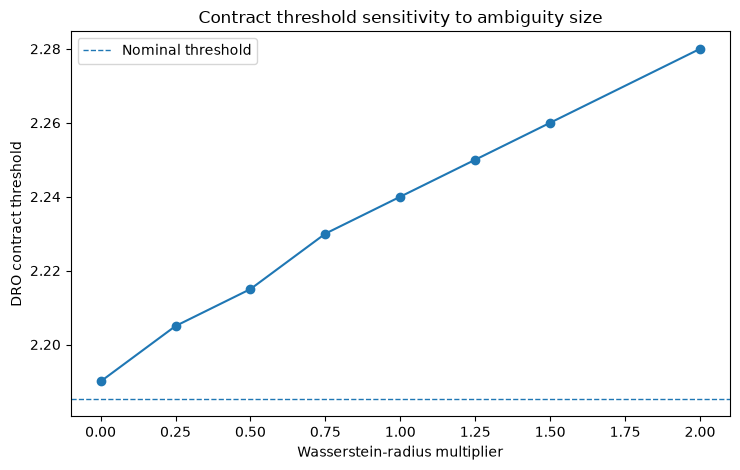

In [18]:
radius_threshold_plot = (
    radius_sensitivity[
        [
            "rho_multiplier",
            "dro_alpha_threshold",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "rho_multiplier"
    )
)

fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)

ax.plot(
    radius_threshold_plot[
        "rho_multiplier"
    ],
    radius_threshold_plot[
        "dro_alpha_threshold"
    ],
    marker="o",
)

ax.axhline(
    baseline_nominal_threshold,
    linestyle="--",
    linewidth=1.0,
    label="Nominal threshold",
)

ax.set_xlabel(
    "Wasserstein-radius multiplier"
)
ax.set_ylabel(
    "DRO contract threshold"
)
ax.set_title(
    "Contract threshold sensitivity to ambiguity size"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    RADIUS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

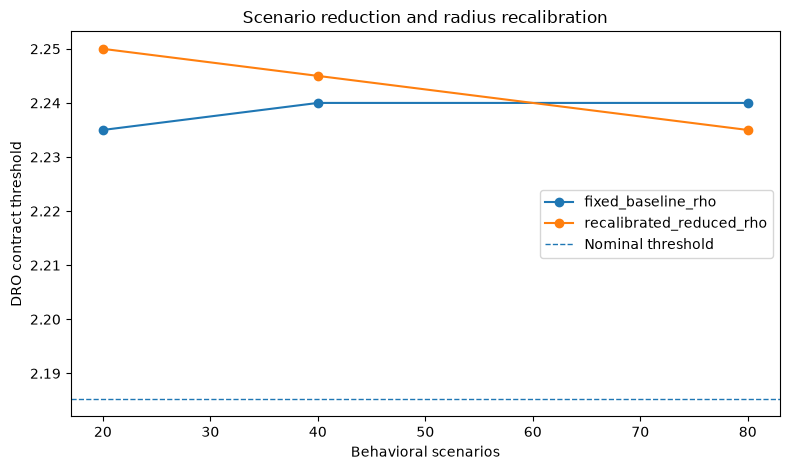

In [19]:
fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)

for radius_mode, group in (
    scenario_sensitivity.groupby(
        "radius_mode",
        observed=True,
    )
):
    ax.plot(
        group[
            "actual_scenario_count"
        ],
        group[
            "dro_alpha_threshold"
        ],
        marker="o",
        label=radius_mode,
    )

ax.axhline(
    baseline_nominal_threshold,
    linestyle="--",
    linewidth=1.0,
    label="Nominal threshold",
)

ax.set_xlabel(
    "Behavioral scenarios"
)
ax.set_ylabel(
    "DRO contract threshold"
)
ax.set_title(
    "Scenario reduction and radius recalibration"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    SCENARIO_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

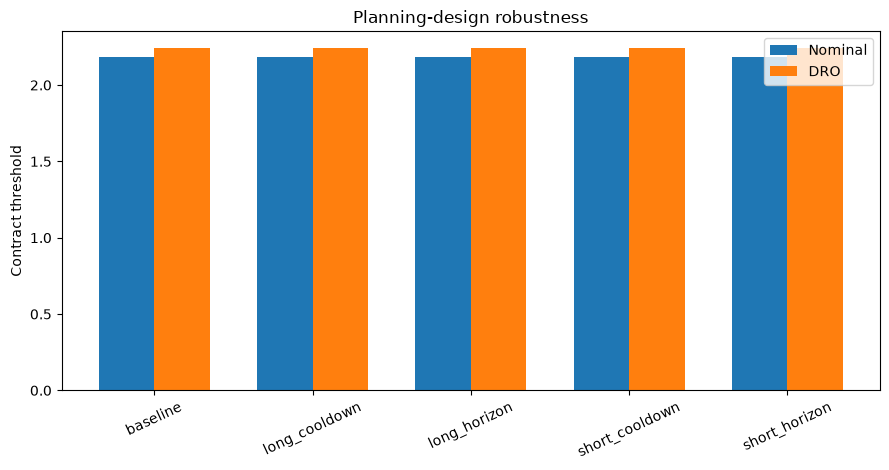

In [20]:
structural_plot = (
    structural_sensitivity.sort_values(
        "configuration"
    )
)

x = np.arange(
    len(
        structural_plot
    ),
    dtype=float,
)

width = 0.35

fig, ax = plt.subplots(
    figsize=(9.0, 4.8)
)

ax.bar(
    x - width / 2,
    structural_plot[
        "nominal_alpha_threshold_exact"
    ],
    width=width,
    label="Nominal",
)

ax.bar(
    x + width / 2,
    structural_plot[
        "dro_alpha_threshold_grid"
    ],
    width=width,
    label="DRO",
)

ax.set_xticks(
    x,
    structural_plot[
        "configuration"
    ],
    rotation=25,
)
ax.set_ylabel(
    "Contract threshold"
)
ax.set_title(
    "Planning-design robustness"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    STRUCTURAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

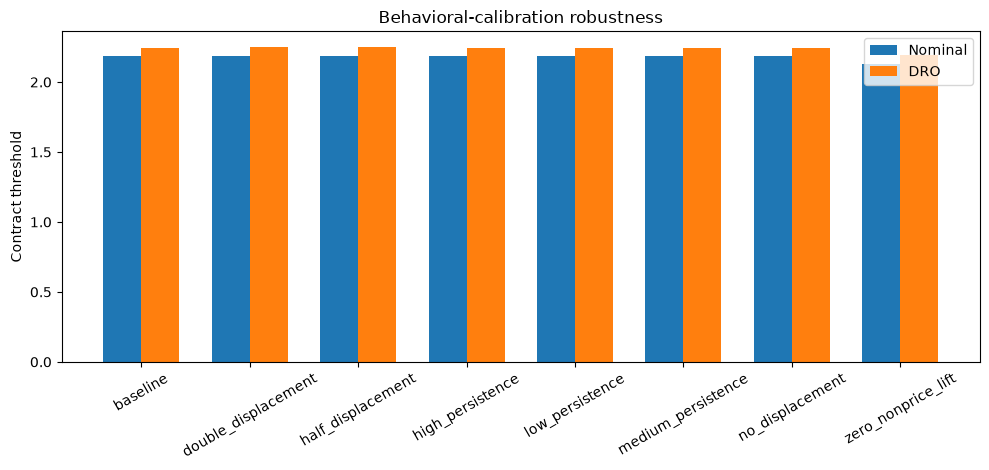

In [21]:
behavioral_plot = (
    behavioral_sensitivity.sort_values(
        "behavioral_variant"
    )
)

x = np.arange(
    len(
        behavioral_plot
    ),
    dtype=float,
)

width = 0.35

fig, ax = plt.subplots(
    figsize=(10.0, 4.8)
)

ax.bar(
    x - width / 2,
    behavioral_plot[
        "nominal_alpha_threshold_exact"
    ],
    width=width,
    label="Nominal",
)

ax.bar(
    x + width / 2,
    behavioral_plot[
        "dro_alpha_threshold_grid"
    ],
    width=width,
    label="DRO",
)

ax.set_xticks(
    x,
    behavioral_plot[
        "behavioral_variant"
    ],
    rotation=30,
)
ax.set_ylabel(
    "Contract threshold"
)
ax.set_title(
    "Behavioral-calibration robustness"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    BEHAVIORAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

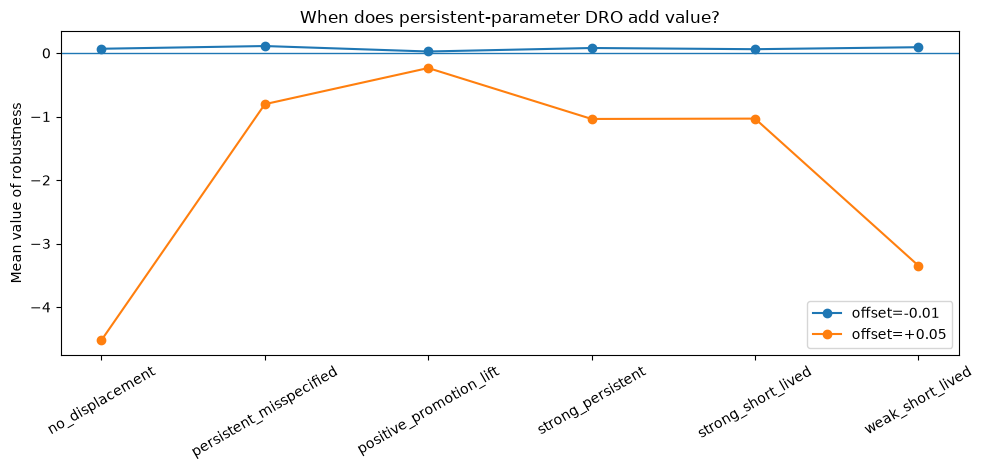

In [22]:
fig, ax = plt.subplots(
    figsize=(10.0, 4.8)
)

simulation_plot = (
    simulation_summary.copy()
)

for offset, group in (
    simulation_plot.groupby(
        "threshold_offset",
        observed=True,
    )
):
    ax.plot(
        group[
            "dgp"
        ],
        group[
            "mean_value_of_robustness"
        ],
        marker="o",
        label=(
            f"offset={offset:+.2f}"
        ),
    )

ax.axhline(
    0.0,
    linewidth=1.0,
)
ax.set_ylabel(
    "Mean value of robustness"
)
ax.set_title(
    "When does persistent-parameter DRO add value?"
)
ax.tick_params(
    axis="x",
    rotation=30,
)
ax.legend()
fig.tight_layout()
fig.savefig(
    SIMULATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

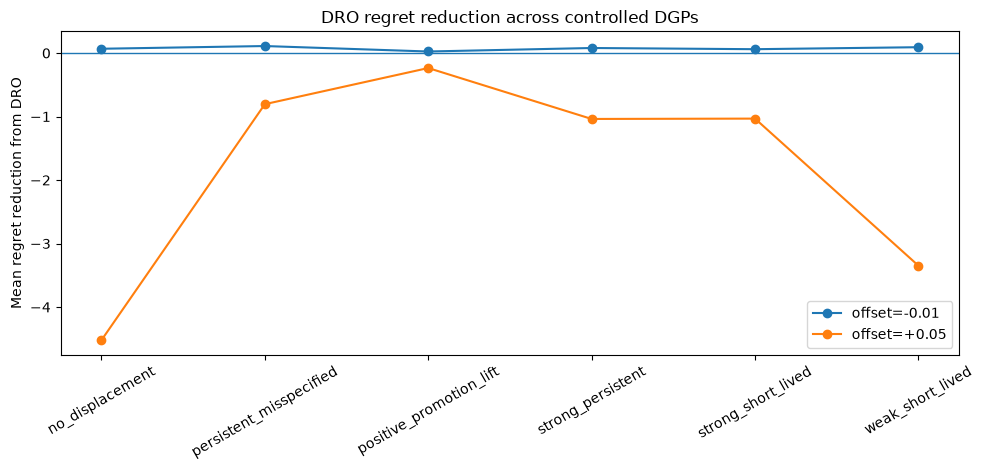

In [23]:
fig, ax = plt.subplots(
    figsize=(10.0, 4.8)
)

for offset, group in (
    simulation_summary.groupby(
        "threshold_offset",
        observed=True,
    )
):
    ax.plot(
        group[
            "dgp"
        ],
        group[
            "mean_regret_reduction_from_dro"
        ],
        marker="o",
        label=(
            f"offset={offset:+.2f}"
        ),
    )

ax.axhline(
    0.0,
    linewidth=1.0,
)
ax.set_ylabel(
    "Mean regret reduction from DRO"
)
ax.set_title(
    "DRO regret reduction across controlled DGPs"
)
ax.tick_params(
    axis="x",
    rotation=30,
)
ax.legend()
fig.tight_layout()
fig.savefig(
    SIMULATION_REGRET_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 14. Save outputs

In [24]:
radius_sensitivity.to_csv(
    RADIUS_SENSITIVITY_PATH,
    index=False,
)

scenario_sensitivity.to_csv(
    SCENARIO_SENSITIVITY_PATH,
    index=False,
)

structural_sensitivity.to_csv(
    STRUCTURAL_SENSITIVITY_PATH,
    index=False,
)

behavioral_sensitivity.to_csv(
    BEHAVIORAL_SENSITIVITY_PATH,
    index=False,
)

simulation_raw.to_csv(
    SIMULATION_RAW_PATH,
    index=False,
)

simulation_summary.to_csv(
    SIMULATION_SUMMARY_PATH,
    index=False,
)

robustness_summary.to_csv(
    ROBUSTNESS_SUMMARY_PATH,
    index=False,
)

configuration = {
    "main_model": (
        "persistent_parameter_open_loop_wasserstein_dro"
    ),
    "radius_multipliers": (
        RADIUS_MULTIPLIERS.tolist()
    ),
    "scenario_counts": (
        SCENARIO_COUNTS
    ),
    "run_full_support": bool(
        RUN_FULL_SUPPORT
    ),
    "structural_configurations": (
        STRUCTURAL_CONFIGURATIONS
    ),
    "behavioral_variants": (
        BEHAVIORAL_VARIANTS
    ),
    "simulation_replications": int(
        SIMULATION_REPLICATIONS
    ),
    "simulation_estimation_draws": int(
        SIMULATION_ESTIMATION_DRAWS
    ),
    "simulation_scenario_count": int(
        SIMULATION_SCENARIO_COUNT
    ),
    "simulation_offsets": (
        SIMULATION_OFFSETS.tolist()
    ),
    "partial_id_probability": float(
        PARTIAL_ID_PROBABILITY
    ),
    "partial_id_grid": (
        PERSISTENCE_PARTIAL_ID_GRID.tolist()
    ),
    "simulation_parameter_sd": (
        SIMULATION_PARAMETER_SD.tolist()
    ),
    "random_seed": int(
        RANDOM_SEED
    ),
}

CONFIGURATION_PATH.write_text(
    json.dumps(
        configuration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Saved radius sensitivity:",
    RADIUS_SENSITIVITY_PATH,
)
print(
    "Saved scenario sensitivity:",
    SCENARIO_SENSITIVITY_PATH,
)
print(
    "Saved structural sensitivity:",
    STRUCTURAL_SENSITIVITY_PATH,
)
print(
    "Saved behavioral sensitivity:",
    BEHAVIORAL_SENSITIVITY_PATH,
)
print(
    "Saved simulation summary:",
    SIMULATION_SUMMARY_PATH,
)

Saved radius sensitivity: C:\Users\janza\price-of-extrapolation\results\tables\robustness_radius_sensitivity.csv
Saved scenario sensitivity: C:\Users\janza\price-of-extrapolation\results\tables\robustness_scenario_reduction.csv
Saved structural sensitivity: C:\Users\janza\price-of-extrapolation\results\tables\robustness_structural_design.csv
Saved behavioral sensitivity: C:\Users\janza\price-of-extrapolation\results\tables\robustness_behavioral_calibration.csv
Saved simulation summary: C:\Users\janza\price-of-extrapolation\results\tables\simulation_validation_summary.csv


## Interpretation checklist

1. The baseline result is robust only when the ordering and qualitative
   policy differences persist over reasonable specifications; exact
   threshold equality is not required.
2. Radius sensitivity should be interpreted as a conservatism frontier,
   not as a search for the radius that makes DRO look best.
3. Scenario reduction must be assessed jointly with radius
   recalibration. Holding \(\rho\) fixed and changing the support can
   alter the meaning of the ambiguity set.
4. The behavioral variants are decision-layer sensitivity checks. They
   do not replace rerunning the raw event-study calibration under
   alternative event definitions.
5. The simulations validate the decision layer under known persistent
   DGPs. They are not an end-to-end simulation of scanner-data
   construction and fixed-effect estimation.
6. Positive value of robustness is not expected in every DGP. A credible
   result should identify both regions where DRO improves outcomes and
   regions where it is unnecessarily conservative.
7. The central simulation outcome is the relationship between
   uncertainty, displacement severity, and the sign of

   \[
   V^{DRO}-V^N.
   \]

8. A final empirical appendix should separately rerun notebook 04 under
   alternative event gaps, promotion thresholds, and persistence grids.